In [1]:
from pathlib import Path
import xarray as xr
from xgcm import Grid
import gsw
import matplotlib.pyplot as plt
import numpy as np
#from scipy.interpolate import interp1d
#from scipy import optimize
import pandas as pd
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
import numpy as np
from scipy.stats import kendalltau
from sklearn.metrics import mean_squared_error

In [2]:
ECCO_version = 'v4r4'
#ECCO_version = 'v4r5'

In [3]:
df = pd.read_csv(f'trends_data_ECCO{ECCO_version}.csv',index_col=0,parse_dates=True)
df['Date'] = df.index
df['Time_numeric'] = (df['Date'] - df['Date'].min()).dt.total_seconds()

In [4]:
df['dz_gb_rm'] = df['dz_gb'].rolling(window=12,center=True).mean()
df['N2_glob_rm'] = df['N2_glob'].rolling(window=12,center=True).mean()
df['dz_gb_timemean_below2000m_rm'] = df['dz_gb_timemean_below2000m'].rolling(window=12,center=True).mean()
df['dz_gb_timemean_below500m_rm'] = df['dz_gb_timemean_below500m'].rolling(window=12,center=True).mean()

#### **Comparison between N2 and Depth Anomaly**

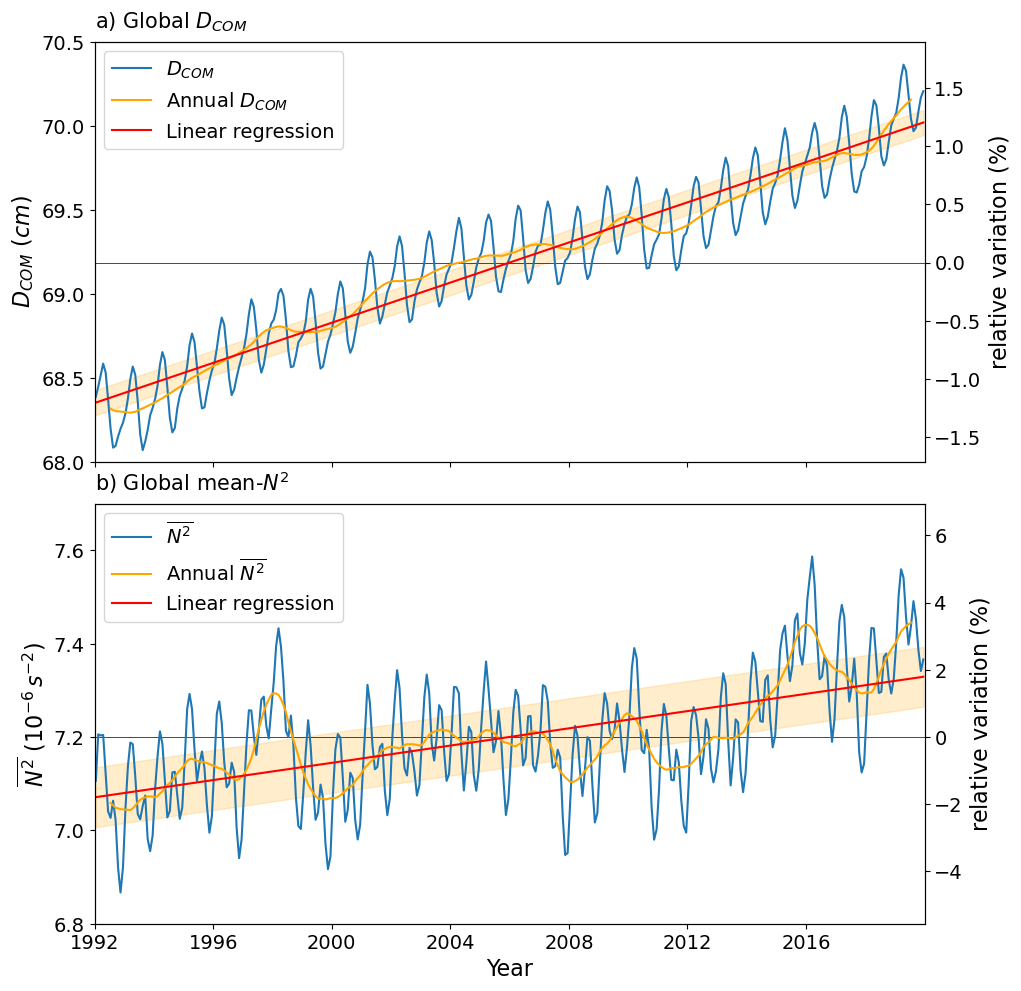

In [5]:
# Skapa subplot
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True)

# ---------------------------
# a) Global trend D_COM
# ---------------------------
X = df[['Time_numeric']].values
y = df['dz_gb'].values * 100

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

stderr = (df['dz_gb']*100 - y_pred).rolling(12, center=True).mean().std()

ax1 = axes[0]
ax12 = ax1.twinx()
ax1.axhline(y=y.mean(),color='k',linewidth=.5)
ax1.plot(df['Date'], y, label='$ D_{COM} $')
ax1.plot(df['Date'], df['dz_gb_rm']*100, color='orange', label='Annual $ D_{COM} $')
ax1.plot(df['Date'], y_pred, color='red', label='Linear regression')
ax1.fill_between(df['Date'], y_pred - stderr, y_pred + stderr, color='orange', alpha=0.2)
            
# Titel till vänster
ax1.text(0.0, 1.02, "a) Global $D_{COM}$", transform=ax1.transAxes,
         fontsize=15, ha='left', va='bottom')

ax1.set_ylabel('$D_{COM}\\ (cm)$', fontsize=16)
ax1.set_ylim(68, 70.5)
ax1.set_xlim(pd.Timestamp("1992-01-01"), pd.Timestamp("2019-12-31"))
ax1.legend(fontsize=14)
ax1.tick_params(labelsize=14)
ax12.set_ylim((68/y.mean()-1)*100, (70.5/y.mean()-1)*100)
ax12.set_ylabel('relative variation ($\%$)', fontsize=16)
ax12.tick_params(labelsize=14)



# ---------------------------
# b) Global trend N²
# ---------------------------
y_n2 = df['N2_glob'].values
y_n2_scaled = y_n2 * 1e6

model = LinearRegression()
model.fit(X, y_n2)
y_pred_n2 = model.predict(X)
y_pred_n2_scaled = y_pred_n2 * 1e6

stderr_n2 = (df['N2_glob'] - y_pred_n2).rolling(12, center=True).mean().std()
stderr_n2_scaled = stderr_n2 * 1e6

ax2 = axes[1]
ax22 = ax2.twinx()
ax2.axhline(y=y_n2_scaled.mean(),color='k',linewidth=.5)
ax2.plot(df['Date'], y_n2_scaled, label='$\overline{N^{2}}$')
ax2.plot(df['Date'], df['N2_glob_rm'] * 1e6, color='orange', label='Annual $\overline{N^{2}}$')
ax2.plot(df['Date'], y_pred_n2_scaled, color='red', label='Linear regression')
ax2.fill_between(df['Date'], y_pred_n2_scaled - stderr_n2_scaled,
                 y_pred_n2_scaled + stderr_n2_scaled, color='orange', alpha=0.2)

# Titel till vänster
ax2.text(0.0, 1.02, "b) Global mean-$N^{2}$", transform=ax2.transAxes,
         fontsize=15, ha='left', va='bottom')

ax2.set_xlabel('Year', fontsize=16)
ax2.set_ylabel('$\overline{N^{2}}$ $(10^{-6}\\,s^{-2})$', fontsize=16)
ax2.ticklabel_format(axis='y', style='plain')
ax2.set_ylim(6.8, 7.7)
ax2.legend(fontsize=14, loc='upper left')
ax2.tick_params(labelsize=14)
ax22.set_ylim(6.8/y_n2_scaled.mean()*100-100, 7.7/y_n2_scaled.mean()*100-100)
ax22.set_ylabel('relative variation ($\%$)', fontsize=16)
ax22.tick_params(labelsize=14)

# Justera layout
plt.tight_layout()
plt.subplots_adjust(left=0.12, right=0.95, hspace=0.10)
plt.savefig(f'Figure2_ECCO{ECCO_version}.png', bbox_inches="tight")
plt.savefig(f'Figure2_ECCO{ECCO_version}.pdf', bbox_inches="tight")
plt.show()


In [6]:
# Behöver göra linjär regression för månad och årlig trendlinje för att ta fram RMSE
# 1. RMSE för linjär regression
rmse_linreg = np.sqrt(mean_squared_error(df['N2_glob'], y_pred))
print(f"RMSE för linjär regression: {rmse_linreg:.3e}")

# 2. RMSE för årligt glidande medelvärde
# Filtrera bort NaN i rullande medelvärde
mask = ~df['N2_glob_rm'].isna()
rmse_rolling = np.sqrt(mean_squared_error(df['N2_glob'][mask], df['N2_glob_rm'][mask]))
print(f"RMSE för årligt glidande medelvärde: {rmse_rolling:.3e}")

RMSE för linjär regression: 6.919e+01
RMSE för årligt glidande medelvärde: 8.229e-08
